In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

In [2]:
X, y = make_blobs(n_samples=300,
                  centers=4,
                  cluster_std=1.0,
                  random_state=42)

df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])
df.head()

,Feature1,Feature2
0,-9.297689,6.473679
1,-9.698741,6.938967
2,-1.686653,7.793442
3,-7.097308,-5.781333
4,-10.876452,6.315437


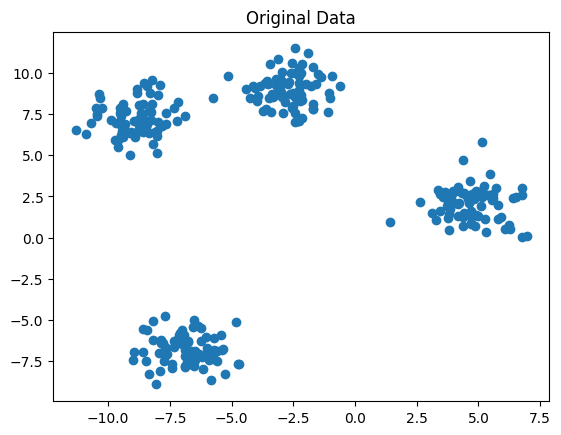

In [3]:
plt.scatter(df['Feature1'], df['Feature2'])
plt.title("Original Data")
plt.show()

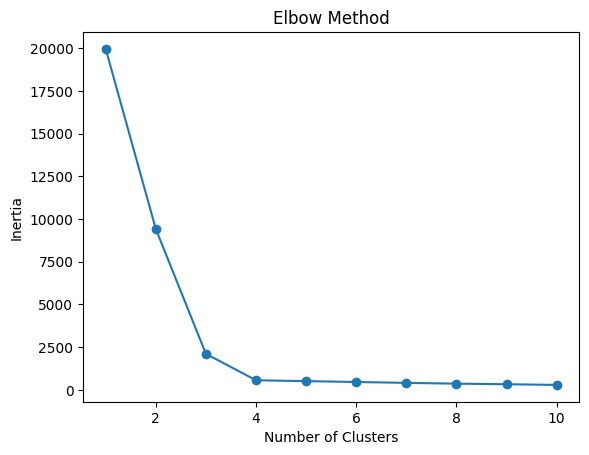

In [4]:
inertia = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [5]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(df)

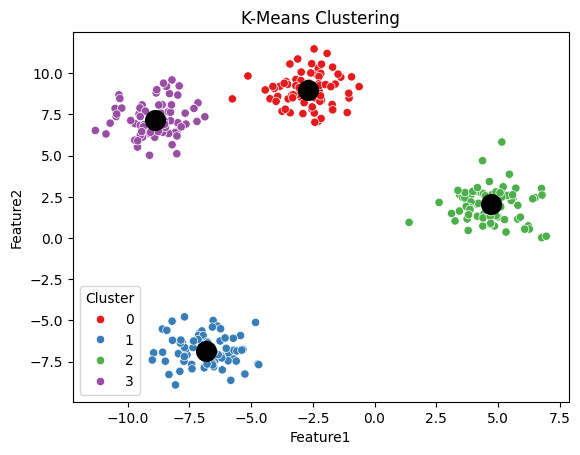

In [6]:
sns.scatterplot(x='Feature1',
                y='Feature2',
                hue='Cluster',
                data=df,
                palette='Set1')

plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=200, c='black')

plt.title("K-Means Clustering")
plt.show()

In [7]:
score = silhouette_score(df[['Feature1','Feature2']], df['Cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.7915830011443039
